# 04 Generate and Inspect Superellipse Pilot Dataset (v2)

Deterministic pilot-v2 dataset in the numerically safer superellipse regime.

No production-scale generation and no ML training are included.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse.linalg import eigsh

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.dataset import generate_superellipse_pilot_dataset
from src.geometry import build_superellipse_dot

In [3]:
out_path = PROJECT_ROOT / "data" / "superellipse_pilot_dataset.npz"
dataset = generate_superellipse_pilot_dataset(save_path=out_path)

expected_count = 3 * 5 * 9
print(f"Saved: {out_path}")
print(f"Sample count: {len(dataset['a'])} (expected {expected_count})")
print(f"a range: {dataset['a'].min()} .. {dataset['a'].max()}")
print(f"aspect_ratio range: {dataset['aspect_ratio'].min()} .. {dataset['aspect_ratio'].max()}")
print(f"n range: {dataset['n'].min()} .. {dataset['n'].max()}")
print(f"N_sites range: {dataset['N_sites'].min()} .. {dataset['N_sites'].max()}")

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\data\superellipse_pilot_dataset.npz
Sample count: 135 (expected 135)
a range: 24.0 .. 36.0
aspect_ratio range: 0.67 .. 1.0
n range: 1.2 .. 4.0
N_sites range: 905 .. 4761


In [4]:
def is_real_finite(arr: np.ndarray) -> bool:
    return bool(np.all(np.isfinite(arr)) and (not np.iscomplexobj(arr)))

e0, e1, e2, e3 = dataset["E0"], dataset["E1"], dataset["E2"], dataset["E3"]
de1, de2, de3 = dataset["dE1"], dataset["dE2"], dataset["dE3"]

ordering_ok = bool(np.all(e0 <= e1) and np.all(e1 <= e2) and np.all(e2 <= e3))

print("Diagnostics:")
print(f"- finite/real energies: {is_real_finite(e0) and is_real_finite(e1) and is_real_finite(e2) and is_real_finite(e3)}")
print(f"- ordering E0<=E1<=E2<=E3: {ordering_ok}")
print(f"- E0 min/max: {e0.min():.6f} .. {e0.max():.6f}")
print(f"- E1 min/max: {e1.min():.6f} .. {e1.max():.6f}")
print(f"- E2 min/max: {e2.min():.6f} .. {e2.max():.6f}")
print(f"- E3 min/max: {e3.min():.6f} .. {e3.max():.6f}")
print(f"- dE1 min/max: {de1.min():.6f} .. {de1.max():.6f}")
print(f"- dE2 min/max: {de2.min():.6f} .. {de2.max():.6f}")
print(f"- dE3 min/max: {de3.min():.6f} .. {de3.max():.6f}")

Diagnostics:
- finite/real energies: True
- ordering E0<=E1<=E2<=E3: True
- E0 min/max: -3.996133 .. -3.978659
- E1 min/max: -3.990280 .. -3.953603
- E2 min/max: -3.990280 .. -3.939449
- E3 min/max: -3.984054 .. -3.923766
- dE1 min/max: 0.005853 .. 0.025056
- dE2 min/max: 0.000000 .. 0.014566
- dE3 min/max: 0.003419 .. 0.022478


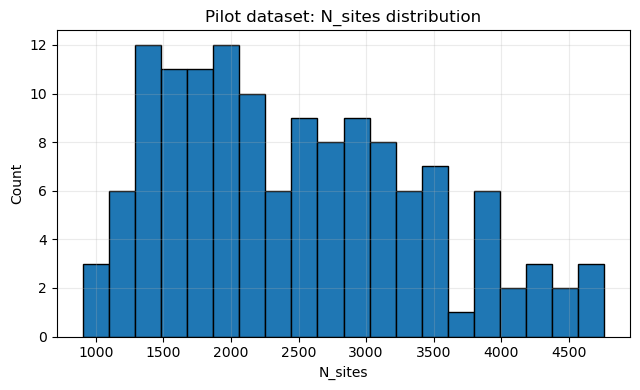

In [5]:
# Distribution of N_sites.
plt.figure(figsize=(6.5, 4))
plt.hist(dataset["N_sites"], bins=20, edgecolor="black")
plt.xlabel("N_sites")
plt.ylabel("Count")
plt.title("Pilot dataset: N_sites distribution")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

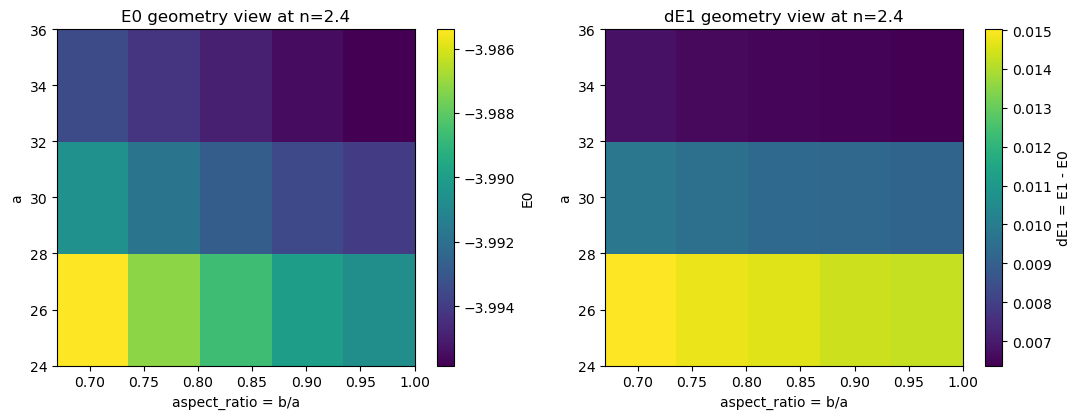

In [6]:
# Heatmap-style view at fixed n to inspect geometry dependence.
n_ref = 2.4
mask_ref = np.isclose(dataset["n"], n_ref)

a_vals = np.unique(dataset["a"])
r_vals = np.unique(dataset["aspect_ratio"])

E0_grid = dataset["E0"][mask_ref].reshape(len(a_vals), len(r_vals))
dE1_grid = dataset["dE1"][mask_ref].reshape(len(a_vals), len(r_vals))

extent = [r_vals.min(), r_vals.max(), a_vals.min(), a_vals.max()]  # x=r, y=a

plt.figure(figsize=(11, 4.3))

plt.subplot(1, 2, 1)
im0 = plt.imshow(E0_grid, origin="lower", extent=extent, aspect="auto")
plt.colorbar(im0, label="E0")
plt.xlabel("aspect_ratio = b/a")
plt.ylabel("a")
plt.title(f"E0 geometry view at n={n_ref}")

plt.subplot(1, 2, 2)
im1 = plt.imshow(dE1_grid, origin="lower", extent=extent, aspect="auto")
plt.colorbar(im1, label="dE1 = E1 - E0")
plt.xlabel("aspect_ratio = b/a")
plt.ylabel("a")
plt.title(f"dE1 geometry view at n={n_ref}")

plt.tight_layout()
plt.show()

In [7]:
def first_four_energies_superellipse(a: float, b: float, n: float) -> np.ndarray:
    """Direct recomputation helper for deterministic rerun checks."""
    fsys = build_superellipse_dot(a=a, b=b, n=n)
    h = fsys.hamiltonian_submatrix(sparse=True).tocsr()
    dim = h.shape[0]
    if dim < 5:
        vals = np.linalg.eigvalsh(h.toarray())[: min(4, dim)]
    else:
        vals, _ = eigsh(h, k=4, which="SA")
    vals = np.sort(np.asarray(vals, dtype=float))
    if vals.shape != (4,):
        raise ValueError("Expected 4 energies for deterministic anchor check.")
    return vals


anchors = [
    (24.0, 0.67, 1.2),
    (30.0, 0.83, 2.4),
    (36.0, 1.0, 4.0),
]

print("Deterministic rerun checks on anchor points:")
for a, r, n in anchors:
    b = r * a
    mask = (
        np.isclose(dataset["a"], a)
        & np.isclose(dataset["aspect_ratio"], r)
        & np.isclose(dataset["n"], n)
    )
    idx = np.where(mask)[0][0]
    from_data = np.array([dataset["E0"][idx], dataset["E1"][idx], dataset["E2"][idx], dataset["E3"][idx]])
    rerun = first_four_energies_superellipse(a=a, b=b, n=n)
    max_abs_diff = float(np.max(np.abs(from_data - rerun)))
    print(f"- (a={a}, r={r}, n={n}): max |stored-rerun| = {max_abs_diff:.3e}")

Deterministic rerun checks on anchor points:
- (a=24.0, r=0.67, n=1.2): max |stored-rerun| = 4.796e-14
- (a=30.0, r=0.83, n=2.4): max |stored-rerun| = 4.841e-14
- (a=36.0, r=1.0, n=4.0): max |stored-rerun| = 3.553e-14


In [8]:
def jump_range_summary(level: np.ndarray, n_sites: np.ndarray) -> tuple[int, float, float, float]:
    """Return (count_jumps, total_range, max_local_jump, ratio)."""
    count_jumps = int(np.sum(np.diff(n_sites) != 0))
    total_range = float(np.max(level) - np.min(level))
    max_local_jump = float(np.max(np.abs(np.diff(level)))) if level.size > 1 else 0.0
    ratio = max_local_jump / total_range if total_range > 0 else np.nan
    return count_jumps, total_range, max_local_jump, ratio


anchor_pairs = [
    (24.0, 0.67),
    (30.0, 0.83),
    (36.0, 1.0),
]

n_coarse_v1 = np.array([1.2, 1.9, 2.6, 3.3, 4.0], dtype=float)

print("Discretization-focused n-variation checks (by fixed a, aspect_ratio):")
for a, r in anchor_pairs:
    mask = np.isclose(dataset["a"], a) & np.isclose(dataset["aspect_ratio"], r)
    order = np.argsort(dataset["n"][mask])

    n_vals_v2 = dataset["n"][mask][order]
    e0_vals_v2 = dataset["E0"][mask][order]
    n_sites_vals_v2 = dataset["N_sites"][mask][order]

    jumps_v2, e0_range_v2, e0_max_jump_v2, e0_ratio_v2 = jump_range_summary(e0_vals_v2, n_sites_vals_v2)

    # Pilot-v1 style coarse n subset recomputed on the same anchors for fair comparison.
    e0_vals_v1 = []
    n_sites_vals_v1 = []
    for n in n_coarse_v1:
        b = r * a
        fsys = build_superellipse_dot(a=a, b=b, n=float(n))
        n_sites_vals_v1.append(len(fsys.sites))
        e0_vals_v1.append(first_four_energies_superellipse(a=a, b=b, n=float(n))[0])
    e0_vals_v1 = np.array(e0_vals_v1, dtype=float)
    n_sites_vals_v1 = np.array(n_sites_vals_v1, dtype=int)
    jumps_v1, e0_range_v1, e0_max_jump_v1, e0_ratio_v1 = jump_range_summary(e0_vals_v1, n_sites_vals_v1)

    print(f"- a={a:.0f}, r={r:.2f}")
    print(f"  v2 dense n: jumps={jumps_v2}, E0_range={e0_range_v2:.3e}, E0_max_jump={e0_max_jump_v2:.3e}, ratio={e0_ratio_v2:.4f}")
    print(f"  v1 coarse n: jumps={jumps_v1}, E0_range={e0_range_v1:.3e}, E0_max_jump={e0_max_jump_v1:.3e}, ratio={e0_ratio_v1:.4f}")
    print(f"  n values v2: {n_vals_v2}")
    print(f"  N_sites v2: {n_sites_vals_v2}")

Discretization-focused n-variation checks (by fixed a, aspect_ratio):
- a=24, r=0.67
  v2 dense n: jumps=8, E0_range=7.918e-03, E0_max_jump=3.513e-03, ratio=0.4437
  v1 coarse n: jumps=4, E0_range=7.918e-03, E0_max_jump=5.573e-03, ratio=0.7038
  n values v2: [1.2 1.5 1.8 2.1 2.4 2.8 3.2 3.6 4. ]
  N_sites v2: [ 905 1057 1153 1233 1293 1345 1381 1409 1425]
- a=30, r=0.83
  v2 dense n: jumps=8, E0_range=3.787e-03, E0_max_jump=1.666e-03, ratio=0.4398
  v1 coarse n: jumps=4, E0_range=3.787e-03, E0_max_jump=2.772e-03, ratio=0.7321
  n values v2: [1.2 1.5 1.8 2.1 2.4 2.8 3.2 3.6 4. ]
  N_sites v2: [1765 2037 2245 2377 2489 2577 2653 2701 2737]
- a=36, r=1.00
  v2 dense n: jumps=8, E0_range=2.194e-03, E0_max_jump=9.810e-04, ratio=0.4472
  v1 coarse n: jumps=4, E0_range=2.194e-03, E0_max_jump=1.574e-03, ratio=0.7176
  n values v2: [1.2 1.5 1.8 2.1 2.4 2.8 3.2 3.6 4. ]
  N_sites v2: [3057 3545 3881 4133 4305 4481 4601 4685 4761]
